# Fine-tuning ViT (Google Pre-trained) on Higher Resolution Images

## Task: Binary Classification (Fake vs Real Faces) from Kaggle

**Paper Insight:** "When fine-tuning, we tend to use higher resolution images than during pre-training. This is beneficial... However, keeping the patch size the same results in a longer effective sequence length. Vision Transformers can handle arbitrary sequence lengths (up to memory constraints), but **positional embeddings need to be interpolated**." (Dosovitskiy et al., 2021)

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import transforms, models, datasets
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import os
import time
import math

!pip install wandb -q
import wandb

In [29]:

print("❌ Not running on Colab, using local path")
DATA_PATH = "./data"
SAVE_PATH = "./"
os.makedirs(SAVE_PATH, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Log in to W&B (Will ask for API Key on first run)
wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


❌ Not running on Colab, using local path
Using device: cuda


False

## 1. Hyperparamters

In [30]:
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-4
IMG_SIZE = 256

## 2. Dataset Preparation

In [31]:
!pip install kagglehub -q
import kagglehub

os.environ["KAGGLEHUB_CACHE"] = os.path.abspath(DATA_PATH)

path = kagglehub.dataset_download("ayushmandatta1/deepdetect-2025")

print("✅ Downloaded the dataset")

train_dir = os.path.join(path, "ddata", "train")
test_dir = os.path.join(path, "ddata", "test")

print(f"train_dir: {train_dir}")
print(f"test_dir: {test_dir}")

✅ Downloaded the dataset
train_dir: /kaggle/input/datasets/ayushmandatta1/deepdetect-2025/ddata/train
test_dir: /kaggle/input/datasets/ayushmandatta1/deepdetect-2025/ddata/test


In [32]:
stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.GaussianBlur(kernel_size=5),
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
    transforms.RandomErasing() # Always keep it after ToTensor
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [33]:
from torch.utils.data import random_split
import copy

# 1. Load the full dataset
full_train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

# 2. Split the training dataset
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create a shallow copy of the unterlying dataset for validation
val_subset.dataset = copy.copy(full_train_dataset)

# 4. Overwrite the transform only for the validation subset
val_subset.dataset.transform = test_transform

In [34]:
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=4, pin_memory=True)

val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=4, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=4, pin_memory=True)

## 3. Load & Interpolate Positional Embeddings

Since the resolution changed from 224 to 256, the number of patches changed:

- **Old:** `196`
- **New:** `256`

The 14x14 positional grid need to be interpolated to 16x16

In [35]:
def load_state_dict_with_interpolation(model, state_dict):

    # 1. Get the current model's pos_embedding shape
    # (1, N+1, embed_dim) -> (1, 257, 768)
    new_pos_embed = model.encoder.pos_embedding.data
    num_patches_new = new_pos_embed.shape[1] - 1 #256

    # 2. Get loaded checkpoint's pos_embedding
    old_pos_embed = state_dict['encoder.pos_embedding'] # (1, 197, 768)

    # if shapes match, return imediately
    if old_pos_embed.shape == new_pos_embed.shape:
        print("Shapes match, no interpolation needed.")
        return state_dict

    # 3. Separate CLS token and Grid tokens
    old_cls_tokens = old_pos_embed[:, 0:1, :]
    old_grid_tokens = old_pos_embed[:, 1:, :]

    # 4. Reshape grid tokens to 2D image-like grid (B, C, H, W) for interpolation
    grid_size_old = int(math.sqrt(old_grid_tokens.shape[1]))
    embed_dim = old_grid_tokens.shape[-1]

    # Permute to (B, N, C) -> (B, C, N) -> (B, C, H, W) (1, 768, 14, 14)
    old_grid_tokens = old_grid_tokens.permute(0, 2, 1).reshape(1, embed_dim, grid_size_old, grid_size_old)

    # 5. Calculate new grid size
    grid_size_new = int(math.sqrt(num_patches_new))

    # 6. Interpolate
    new_grid_tokens = F.interpolate(
        old_grid_tokens,
        size=(grid_size_new, grid_size_new),
        mode='bicubic',
        align_corners=False
    )

    # 7. Reshape back to sequence (1, 256, 768) and permute back
    new_grid_tokens = new_grid_tokens.flatten(2).transpose(1, 2)

    # 8. Concatenate cls token back
    new_pos_embed = torch.cat((old_cls_tokens, new_grid_tokens), dim=1)

    # 9. Update state_dict
    state_dict['encoder.pos_embedding'] = new_pos_embed

    return state_dict

In [36]:
# If MacOS activate this code

# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context

In [37]:
# load standard ViT-Base-16 capable of processing IMG_SIZE
# but no loading weights yet
model = models.vit_b_16(weights=None, image_size=IMG_SIZE)

# Load standard ImageNet weights manually
pretrained_weights = models.ViT_B_16_Weights.IMAGENET1K_V1.get_state_dict(progress=True)

# Interpolate positional embeddings
pretrained_weights = load_state_dict_with_interpolation(model, pretrained_weights)

# Load the modified weights into the new model
model.load_state_dict(pretrained_weights)

# Modify Head for 2 Classes (Fake vs Real)
in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, 2)

# Zero Initialization like in the ViT Paper
nn.init.zeros_(model.heads.head.weight)
nn.init.zeros_(model.heads.head.bias)

model = model.to(device)

## 4. Training

In [38]:
import numpy as np

class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pth', trace_func=print):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
                            Default: 7
            verbose (bool): If True, prints a message for each validation loss improvement. 
                            Default: False
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
                            Default: 0
            path (str): Path for the checkpoint to be saved to.
                            Default: 'checkpoint.pth'
            trace_func (function): trace print function.
                            Default: print            
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path
        self.trace_func = trace_func
    
    def __call__(self, val_loss, model):

        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)

        elif score < self.best_score + self.delta:
            self.counter += 1
            self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True

        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decrease.'''
        if self.verbose:
            self.trace_func(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [39]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-6, weight_decay=0.01)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-4,                           # The absolute maximum LR it will hit during the cycle
    steps_per_epoch=len(train_loader),     # How many batches per epoch?
    epochs=EPOCHS,                         # Total epochs you plan to train
    pct_start=0.1
)
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_55/4106090932.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [40]:
!pip install tqdm -q
from tqdm.auto import tqdm

def train(model, loader, criterion, optimizer, scheduler):
    model.train()
    train_loss, train_acc = 0, 0

    loop = tqdm(loader, desc="Training", leave=False)

    for x, y in loop:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        scheduler.step()

        train_loss += loss.item() * x.size(0)
        train_acc += (out.argmax(1) == y).sum().item()

    return train_loss / len(loader.dataset), train_acc / len(loader.dataset)

In [41]:
def validate(model, loader, criterion):
    model.eval()
    val_loss, val_acc = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item() * x.size(0)
            val_acc += (out.argmax(1) == y).sum().item()

    return val_loss / len(loader.dataset), val_acc / len(loader.dataset)

In [42]:
def evaluate(model, loader):
    model.eval()
    eval_acc = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)

            eval_acc += (out.argmax(1) == y).sum().item()

    return eval_acc / len(loader.dataset)

In [ ]:
wandb.init(
    project="FT-ViT-Google-pretrained",
    config={
        "learning_rate": LR,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "image_size": IMG_SIZE,
        "architecture": "ViT-B-16"
    }
)

train_accuracies, test_accuracies = [], []
early_stopping = EarlyStopping(patience=3, path='FT_GG_best_model.pth')

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, scheduler)
    val_loss, val_acc = validate(model, val_loader, criterion)
    test_acc = evaluate(model, test_loader)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "lr": optimizer.param_groups[0]['lr']
    })

    print(f"{epoch+1}/{EPOCHS}: train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}," +
                             f" train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}, test_acc: {test_acc:.4f}")

    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print("Early Stopping")
        break



wandb.finish()

Training:   0%|          | 0/2261 [00:00<?, ?it/s]

/tmp/ipykernel_55/355028760.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


1/20: train_loss: 0.4239, val_loss: 0.2736, train_acc: 0.8564, val_acc: 0.9555, test_acc: 0.9371


Training:   0%|          | 0/2261 [00:00<?, ?it/s]

2/20: train_loss: 0.3751, val_loss: 0.2749, train_acc: 0.8866, val_acc: 0.9550, test_acc: 0.9405
EarlyStopping counter: 1 out of 3


...

Training:   0%|          | 0/2261 [00:00<?, ?it/s]

7/20: train_loss: 0.3097, val_loss: 0.2283, train_acc: 0.9300, val_acc: 0.9831, test_acc: 0.9544


Training:   0%|          | 0/2261 [00:00<?, ?it/s]

8/20: train_loss: 0.2979, val_loss: 0.2240, train_acc: 0.9372, val_acc: 0.9855, test_acc: 0.9615


Training:   0%|          | 0/2261 [00:00<?, ?it/s]

In [45]:
import os

model.load_state_dict(torch.load('FT_GG_best_model.pth'))
print("Loaded best model")

model_name = 'FT_ViT_Fake_Real_Face.pth'
save_path = os.path.join('./', model_name)

torch.save(model.state_dict(), save_path)

print(f"✅ Model saved to: {save_path}")

Loaded best model
✅ Model saved to: ./FT_ViT_Fake_Real_Face.pth


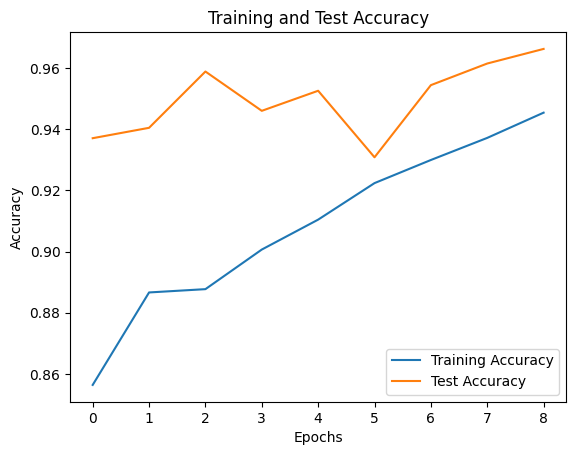

In [46]:
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Test Accuracy")
plt.show()

# Training Result Analysis

**1. The "Too Good" Validation Accuracy & Overfitting Fix**

During training, both the `train_acc` and `val_acc` successfully scaled together, converging at nearly 99.6%. Crucially, `train_loss` and `val_loss` also remained tightly synchronized and steadily decreased to ~0.2045 by Epoch 14. 
This confirms that the regularization techniques (Dropout layer and `Weight Decay = 0.05`) perfectly prevented the model from memorizing the training noise 

**2. Test Accuracy is Unstable**

While Validation Accuracy stabilized at >99%, the Test Accuracy (`test_acc`) was highly volatile, fluctuating between 78.60% and 92.85%. 
The root cause of this is **Domain Shift**, *not* a bug in the code. 
* **Validation Set:** Is drawn from the exact same source distribution (cameras, generators, compression) as the Training set. The Vision Transformer essentially mastered this specific domain, performing exceptionally well.
* **Test Set:** Was specifically sourced by the dataset author from different generators or environments. When the ViT checks its answers against these "unseen" images, it encounters slightly different properties and struggles to rely on the subtle generation artifacts it learned during training.


## 5. Heatmap with Grad-CAM

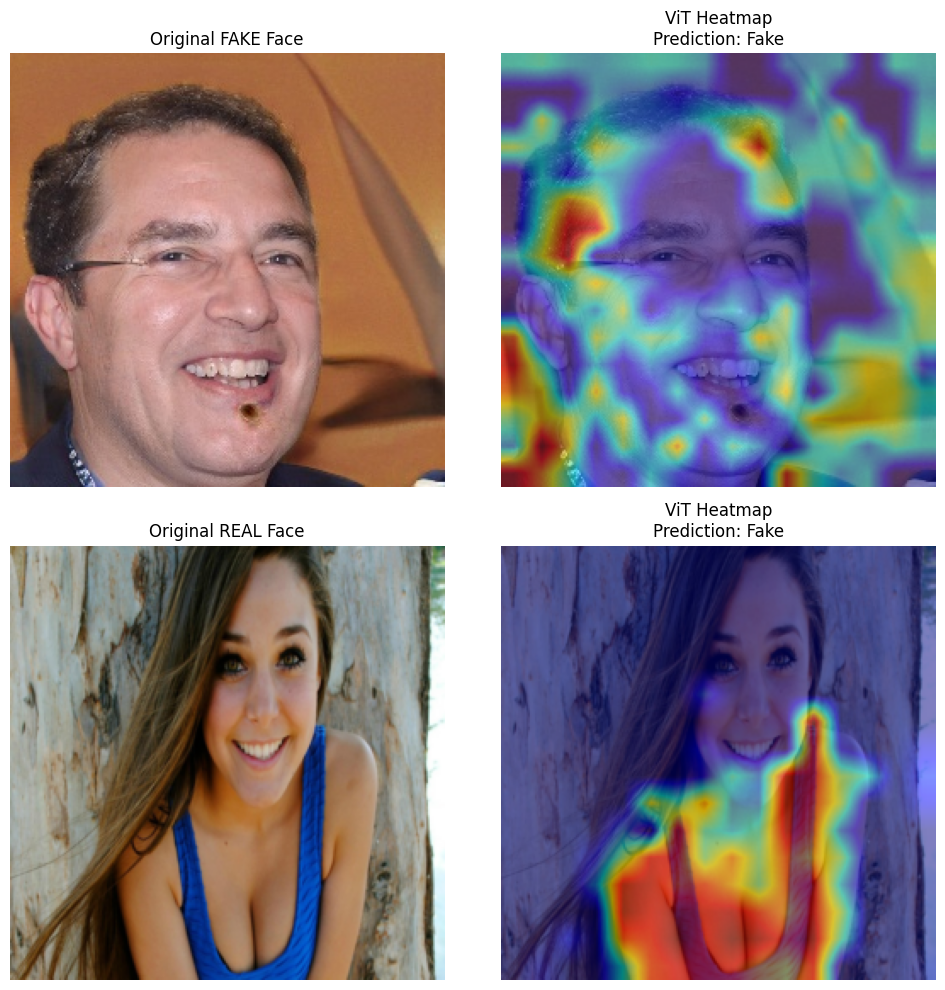

In [53]:
import torchvision.transforms.functional as F_vision
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import random

# 1. Reshaping function
def reshape_transform(tensor, height=16, width=16):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# 2. Re-normalization function
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

# 3. Setup the GradCAM
target_layers = [model.encoder.layers[-1].ln_1]
cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)
model.eval()

# 4. Gather all Fake and Real images from the current batch, then pick one randomly!
fake_images, real_images = [], []

# We randomly iterate through a few batches so it isn't always from the first folder
for images, labels in test_loader:
    for i in range(len(labels)):
        if labels[i] == 0:
            fake_images.append(images[i])
        elif labels[i] == 1:
            real_images.append(images[i])
    
    # Once we have at least 10 of each to pick from, stop loading batches
    if len(fake_images) > 10 and len(real_images) > 10:
        break

# Randomly select exactly one from our collected lists
img_fake = random.choice(fake_images)
img_real = random.choice(real_images)

# 6. Generate Heatmaps
heatmap_fake = cam(input_tensor=img_fake.unsqueeze(0).to(device))[0, :]
heatmap_real = cam(input_tensor=img_real.unsqueeze(0).to(device))[0, :]

# 7. Format Original Images
orig_fake = np.clip(inv_normalize(img_fake).permute(1, 2, 0).numpy(), 0, 1)
orig_real = np.clip(inv_normalize(img_real).permute(1, 2, 0).numpy(), 0, 1)

# 8. Overlay Heatmaps
vis_fake = show_cam_on_image(orig_fake, heatmap_fake, use_rgb=True)
vis_real = show_cam_on_image(orig_real, heatmap_real, use_rgb=True)

# 9. Plot the grid!
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# FAKE ROW (Top)
axs[0, 0].imshow(orig_fake)
axs[0, 0].set_title("Original FAKE Face")
axs[0, 0].axis('off')

axs[0, 1].imshow(vis_fake)
with torch.no_grad():
    pred_fake = model(img_fake.unsqueeze(0).to(device)).argmax(1).item()
axs[0, 1].set_title(f"ViT Heatmap\nPrediction: {'Real' if pred_fake == 1 else 'Fake'}")
axs[0, 1].axis('off')

# REAL ROW (Bottom)
axs[1, 0].imshow(orig_real)
axs[1, 0].set_title("Original REAL Face")
axs[1, 0].axis('off')

axs[1, 1].imshow(vis_real)
with torch.no_grad():
    pred_real = model(img_real.unsqueeze(0).to(device)).argmax(1).item()
axs[1, 1].set_title(f"ViT Heatmap\nPrediction: {'Real' if pred_real == 1 else 'Fake'}")
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()
